# Recipe 3 — Find Tracks Overlapping a Genomic Region

This notebook walks through querying the FILER coordinate-overlap endpoint to find all
tracks whose intervals intersect a genomic region of interest.

**What you'll learn:**
- How to query the FILER coordinate-overlap endpoint
- How to use `count_only` vs full metadata modes
- How to apply `filterString` to narrow results by metadata
- How to explore and summarize overlapping tracks
- How to save results for downstream workflows

**Use when:** you have a specific locus of interest (e.g., a GWAS hit, a candidate enhancer)
and want to discover which FILER tracks have signal there.

**Next steps after this notebook:**
- `01_track_discovery.ipynb` — pre-filter the track universe before querying
- `02_query_and_summarize.ipynb` — batch-query a BED file of regions

Run the following before starting:
```
pip install -e ".[dev]"
```

---
## 0. Setup

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

In [2]:
from filerpy.client import get_overlapping_tracks, ENDPOINTS

In [3]:
print(f"FILER coordinate-overlap endpoint: {ENDPOINTS['region_overlaps']}")

FILER coordinate-overlap endpoint: https://tf.lisanwanglab.org/FILER2/get_overlapping_tracks_by_coord.php


---
## 1. Hello World — count tracks overlapping a region

The fastest way to verify your connection is to request overlap counts only (`countOnly=1`).
This returns just the track `identifier` and `num_overlaps` — no full metadata fetched.

In [30]:
results = get_overlapping_tracks(
    "chr1:100000-200000",
    "hg38",
    countOnly=1,
)
print(f"Tracks with overlaps: {len(results)}")
print(json.dumps(results[:3], indent=2))

Tracks with overlaps: 15277
[
  {
    "identifier": "NGADBDWBBCVVVX",
    "num_overlaps": 1
  },
  {
    "identifier": "NGADBMAZQ6XEUU",
    "num_overlaps": 1
  },
  {
    "identifier": "NGADB652Z6BORJ",
    "num_overlaps": 1
  }
]


---
## 2. Configure your query

Edit the parameters below to match your locus of interest.

| Parameter | PHP param | Notes |
|---|---|---|
| `region` | `region` | Format: `chrN:start-end` |
| `genome_build` | `genomeBuild` | `hg19`, `hg38`, or `hg38-lifted` |
| `count_only` | `countOnly` | `1` = counts only (fast), `0` = include download URLs |
| `full_metadata` | `fullMetadata` | `1` = all 36 metadata columns; **required for `filterString`** |
| `filter_string` | `filterString` | jq-style boolean expression; requires `full_metadata=1` |

> ⚠️ `filterString` requires `fullMetadata=1`. Without it, metadata fields are absent and
> every filter evaluates to `null == "value"`, returning empty results.

In [31]:
# ── Edit these parameters to match your use case ───────────────────────────
REGION        = "chr1:100000-200000"  # required
GENOME_BUILD  = "hg38"               # required: "hg19", "hg38", or "hg38-lifted"
COUNT_ONLY    = 0                    # 0 = full results, 1 = counts only (fastest)
FULL_METADATA = 1                    # 1 = all metadata columns; required for filterString
FILTER_STRING = None                 # e.g. '.data_source == "ENCODE"', or None for all
# ───────────────────────────────────────────────────────────────────────────

In [32]:
# Auto-enable full_metadata when a filter is provided
if FILTER_STRING:
    FULL_METADATA = 1
    COUNT_ONLY = 0
    print("filterString detected — forcing full_metadata=1 and count_only=0")

In [33]:
print(f"Region        : {REGION}")
print(f"Genome build  : {GENOME_BUILD}")
print(f"Count only    : {COUNT_ONLY}")
print(f"Full metadata : {FULL_METADATA}")
print(f"Filter string : {FILTER_STRING}")

Region        : chr1:100000-200000
Genome build  : hg38
Count only    : 0
Full metadata : 1
Filter string : None


---
## 3. Run the query

In [34]:
print(f"Querying FILER for region: {REGION} ({GENOME_BUILD})...")

Querying FILER for region: chr1:100000-200000 (hg38)...


In [35]:
data = get_overlapping_tracks(
    REGION,
    GENOME_BUILD,
    countOnly=COUNT_ONLY,
    fullMetadata=FULL_METADATA,
    **({"filterString": FILTER_STRING} if FILTER_STRING else {}),
)
df = pd.DataFrame(data)

In [36]:
print(f"\nTracks with overlaps: {len(df)}")
print(df.head().to_string())


Tracks with overlaps: 15277
       identifier   data_source                                             file_name  number_of_intervals  bp_covered                  output_type genome_build    cell_type biosample_type biosamples_term_id tissue_category encode_experiment_id biological_replicate technical_replicate        antibody     assay            file_format  file_size                                                                                                   filepath downloaded_date release_date date_added_to_filer                                                                                                                                                       processed_file_download_url                processed_file_md5                                                                                                                                                                                                                                                                  

### 3a. View key columns only

In [11]:
# Adjust KEY_COLS depending on what was returned
available_cols = df.columns.tolist()

In [12]:
PREFERRED_COLS = [
    "identifier", "assay", "cell_type", "tissue_category",
    "life_stage", "data_source", "output_type", "track_name", "num_overlaps",
]
KEY_COLS = [c for c in PREFERRED_COLS if c in available_cols]

In [13]:
print(f"Displaying columns: {KEY_COLS}")
print(df[KEY_COLS].head(10).to_string())

Displaying columns: ['identifier', 'assay', 'cell_type', 'tissue_category', 'life_stage', 'data_source', 'output_type', 'track_name', 'num_overlaps']
       identifier     assay    cell_type tissue_category life_stage   data_source                  output_type                                                                                              track_name  num_overlaps
0  NGADBDWBBCVVVX  ATAC-seq        H1703            Lung    Unknown  ATACdb_v1.03  accessible chromatin region       ATACdb_v1.03 H1703 ATAC-seq accessible chromatin region (narrowPeak-lifted) [Life stage: Unknown]             1
1  NGADBMAZQ6XEUU  ATAC-seq        H1703            Lung    Unknown  ATACdb_v1.03  accessible chromatin region       ATACdb_v1.03 H1703 ATAC-seq accessible chromatin region (narrowPeak-lifted) [Life stage: Unknown]             1
2  NGADB652Z6BORJ  ATAC-seq  UCLA1 hESCs          Embryo     Embryo  ATACdb_v1.03  accessible chromatin region  ATACdb_v1.03 UCLA1 hESCs ATAC-seq accessible chroma

### 3b. Advanced: raw jq `filterString` examples

For power users — pass a raw jq expression for full Boolean flexibility.
Re-run section 2 and 3 after changing `FILTER_STRING`.

```python
# Single condition
FILTER_STRING = '.data_source == "ENCODE"'

# Multiple AND conditions
FILTER_STRING = '.data_source == "ENCODE" and .assay == "ATAC-seq" and .tissue_category == "Blood" and .life_stage == "Adult"'

# OR across data sources
FILTER_STRING = '(.data_source == "ENCODE" or .data_source == "Blueprint") and .output_type == "peaks"'

# No filter — return all overlapping tracks
FILTER_STRING = None
```

---
## 4. Explore the results

Before downstream use, understand the shape of your results.
*(Cells below are skipped automatically if metadata columns are absent.)*

In [37]:
if "data_source" in df.columns:
    print("=== Tracks by data_source ===")
    print(df["data_source"].value_counts().to_string())
else:
    print("data_source not available — re-run with full_metadata=1")

=== Tracks by data_source ===
data_source
ENCODE                       8791
Blueprint                    1059
ATACdb_v1.03                  861
EpiMap                        831
CEEHRC                        726
TF-footprint-atlas            622
ROADMAP-lifted                583
FANTOM5                       536
HOMER                         409
GTEx_v8                       225
Factorbook                    223
eQTL_Catalogue                185
ROADMAP                       127
DASHR2                         87
Inferno_Genomic_Partition       3
DASHR2_small_RNA_Genes          2
EpiMap_Enhancers                2
EpiHK                           1
Gencode                         1
PhastCons                       1
Repeats                         1
ROADMAP_Enhancers               1


In [38]:
if "assay" in df.columns:
    print("=== Tracks by assay ===")
    print(df["assay"].value_counts().to_string())
else:
    print("assay not available — re-run with full_metadata=1")

=== Tracks by assay ===
assay
DNase-seq              4771
ChIP-seq               1995
Histone ChIP-seq       1639
ATAC-seq               1369
ChromHMM                961
TF ChIP-seq             927
WGB-Seq                 820
Mint-ChIP-seq           709
Motif finding           632
hCAGE                   527
eQTL                    241
sQTL                    169
eCLIP                   124
ChIA-PET                111
RAMPAGE                  75
short total RNA-Seq      72
GM DNase-seq             72
FAIRE-seq                20
Small RNA-Seq            15
PAS-seq                  11
LQhCAGE                   9
Annotation                7
repeats                   1


In [39]:
if "tissue_category" in df.columns:
    print("=== Tracks by tissue_category ===")
    print(df["tissue_category"].value_counts().to_string())
else:
    print("tissue_category not available — re-run with full_metadata=1")

=== Tracks by tissue_category ===
tissue_category
Blood                  4947
Brain                  1787
Digestive              1179
Embryo                  691
Skin                    653
Lung                    590
Immune                  503
Skeletal Muscle         451
Not applicable          417
Heart                   415
Liver                   376
Kidney                  338
Endocrine               263
Blood Vessel            260
Female Reproductive     252
Bone                    244
Immune Organ            211
Male Reproductive       204
iPSC                    201
Breast                  199
Connective Tissue       198
Placenta                151
Stem Cell               143
Eye                     133
Nervous                 114
Adipose                 106
Urinary                  93
Umbilical Cord           82
Muscle                   27
Pancreas                 22
Skeleton                 12
Olfactory                 7
Hair Follicle             5
Throat                    

In [40]:
if "num_overlaps" in df.columns:
    print("=== num_overlaps distribution ===")
    print(df["num_overlaps"].describe())

=== num_overlaps distribution ===
count    15277.000000
mean        32.815474
std        553.222272
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      66376.000000
Name: num_overlaps, dtype: float64


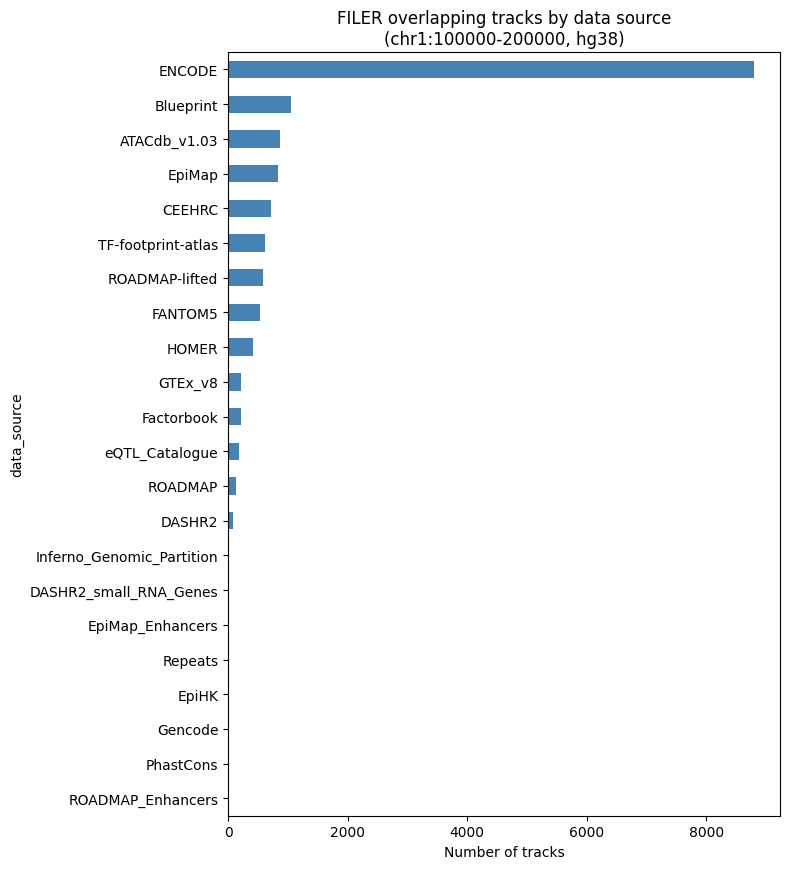

In [18]:
# Bar chart — tracks per data source (only when metadata is available)
if "data_source" in df.columns:
    counts = df["data_source"].value_counts()
    fig, ax = plt.subplots(figsize=(8, max(3, len(counts) * 0.4)))
    counts.sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_xlabel("Number of tracks")
    ax.set_title(f"FILER overlapping tracks by data source\n({REGION}, {GENOME_BUILD})")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart — data_source not available")

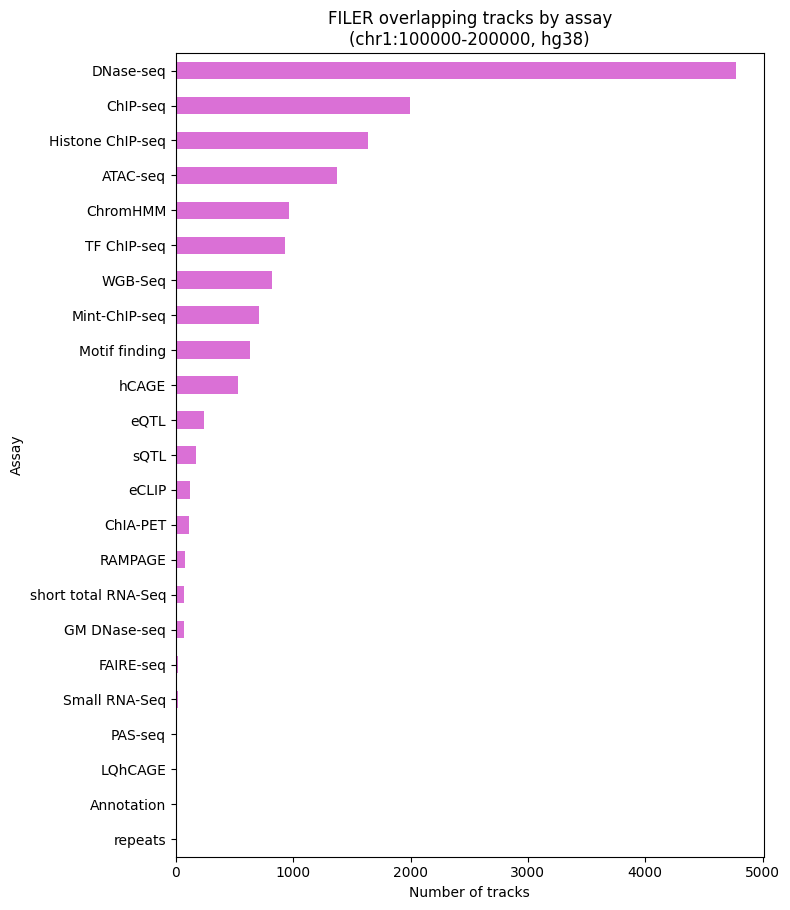

In [19]:
# Bar chart — tracks per assay
if "assay" in df.columns:
    assay_counts = df["assay"].value_counts()
    fig, ax = plt.subplots(figsize=(8, max(3, len(assay_counts) * 0.4)))
    assay_counts.sort_values().plot.barh(ax=ax, color="orchid")
    ax.set_xlabel("Number of tracks")
    ax.set_ylabel("Assay")
    ax.set_title(f"FILER overlapping tracks by assay\n({REGION}, {GENOME_BUILD})")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart — assay not available")

---
## 5. Refine your selection

Post-query filtering in pandas — useful for narrowing results without re-querying the API.

In [41]:
if "life_stage" in df.columns and "num_overlaps" in df.columns:
    # ── Edit these conditions to match what you need ────────────────────────
    df_filtered = df[
        (df["life_stage"] == "Adult") &
        (df["num_overlaps"] >= 1)
    ].copy()
    # ─────────────────────────────────────────────────────────────────────────

    print(f"After refinement: {len(df_filtered)} tracks (from {len(df)} total)")
    print(df_filtered[KEY_COLS].head().to_string())
else:
    df_filtered = df.copy()
    print("Metadata columns not available for refinement — using full result set")

After refinement: 7799 tracks (from 15277 total)
         identifier     assay     cell_type tissue_category life_stage data_source output_type                                                                              track_name  num_overlaps
861  NGBLPGE3OCOEBT  ChIP-seq        B cell           Blood      Adult   Blueprint       peaks        Blueprint B cell ChIP-seq H3K36me3-histone-mark peaks (bed6) [Life stage: Adult]             3
862  NGBLPHEEXV5GAX  ChIP-seq        B cell           Blood      Adult   Blueprint       peaks         Blueprint B cell ChIP-seq H3K9me3-histone-mark peaks (bed6) [Life stage: Adult]             1
872  NGBLPRODH2WCSU  ChIP-seq  Myeloid cell           Blood      Adult   Blueprint       peaks   Blueprint Myeloid cell ChIP-seq H3K27ac-histone-mark peaks (bed6) [Life stage: Adult]             1
874  NGBLP2NNSULYVC  ChIP-seq  Myeloid cell           Blood      Adult   Blueprint       peaks   Blueprint Myeloid cell ChIP-seq H3K4me1-histone-mark peaks (bed6) 

In [21]:
# Sanity check: are all identifiers unique?
if "identifier" in df_filtered.columns:
    n_dupes = df_filtered["identifier"].duplicated().sum()
    print(f"Duplicate identifiers: {n_dupes}")
    if n_dupes > 0:
        print("Deduplicating...")
        df_filtered = df_filtered.drop_duplicates("identifier")

Duplicate identifiers: 0


---
## 6. Save results

### 6a. Save as TSV

In [22]:
repo_root = Path().resolve().parents[1]
out_dir = repo_root / "output" / "03-coordinate-search"
out_dir.mkdir(parents=True, exist_ok=True)

In [23]:
tsv_path = out_dir / "search_results.tsv"
df_filtered.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved {len(df_filtered)} tracks → {tsv_path}")

Saved 7799 tracks → /Users/divak2004/Documents/GitHub/FILER-workflows/output/03-coordinate-search/search_results.tsv


### 6b. Save query provenance (recommended for reproducibility)

Saves the exact parameters used alongside results so the query is fully reproducible.

In [24]:
provenance = {
    "query": {
        "region":        REGION,
        "genome_build":  GENOME_BUILD,
        "count_only":    COUNT_ONLY,
        "full_metadata": FULL_METADATA,
        "filter_string": FILTER_STRING,
    },
    "results": {
        "total_overlapping": len(df),
        "after_refinement":  len(df_filtered),
    },
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "endpoint":  ENDPOINTS["region_overlaps"],
}

In [25]:
prov_path = out_dir / "search_provenance.json"
with open(prov_path, "w") as f:
    json.dump(provenance, f, indent=2)

In [26]:
print(f"Provenance saved → {prov_path}")
print(json.dumps(provenance, indent=2))

Provenance saved → /Users/divak2004/Documents/GitHub/FILER-workflows/output/03-coordinate-search/search_provenance.json
{
  "query": {
    "region": "chr1:100000-200000",
    "genome_build": "hg38",
    "count_only": 0,
    "full_metadata": 1,
    "filter_string": null
  },
  "results": {
    "total_overlapping": 15277,
    "after_refinement": 7799
  },
  "timestamp": "2026-03-16T20:46:34.110251+00:00",
  "endpoint": "https://tf.lisanwanglab.org/FILER2/get_overlapping_tracks_by_coord.php"
}


---
## 7. Batch queries across multiple regions

If you need overlaps for multiple loci, loop and concatenate.
For large BED files, use Recipe 3.2 (batch-query script) instead. 
Please refrain from inputting too many regions as this would overload the server

In [42]:
regions_of_interest = [
    "chr1:100000-200000",
    "chr2:500000-600000",
    "chr3:1000000-1100000",
]

In [43]:
frames = []
for region in regions_of_interest:
    data = get_overlapping_tracks(region, GENOME_BUILD, countOnly=1)
    chunk = pd.DataFrame(data)
    chunk["query_region"] = region
    frames.append(chunk)
    print(f"  {region} → {len(chunk)} overlapping tracks")

  chr1:100000-200000 → 15277 overlapping tracks
  chr2:500000-600000 → 29181 overlapping tracks
  chr3:1000000-1100000 → 22857 overlapping tracks


In [44]:
df_batch = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows across all regions: {len(df_batch)}")
print(df_batch.head().to_string())


Total rows across all regions: 67315
       identifier  num_overlaps        query_region
0  NGADBDWBBCVVVX             1  chr1:100000-200000
1  NGADBMAZQ6XEUU             1  chr1:100000-200000
2  NGADB652Z6BORJ             1  chr1:100000-200000
3  NGADBAWYMQI5FK             1  chr1:100000-200000
4  NGADBANJ54WV2A             1  chr1:100000-200000


---
## 8. Next steps

You now have a `search_results.tsv` and `search_provenance.json` ready for downstream use.

| What to do next | Recipe / Notebook |
|---|---|
| Pre-filter the track universe before querying | Recipe 1 / `01_track_discovery.ipynb` |
| Batch-query a BED file of regions | Recipe 3.2 |
| Summarize overlaps by assay / cell type | Recipe 4.1 |
| Deploy tracks locally for fast offline queries | Recipe 2.2 |

```python
# Quick reference: reload your saved results in a future session
import pandas as pd
df = pd.read_csv("output/03-coordinate-search/search_results.tsv", sep="\t")
print(df.head())
```